In [4]:
import numpy as np
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_array

# 1. Génération de données de démonstration (points 2D)
# Nous avons 6 points, qui seront nos nœuds dans le graphe.
X = np.array([
    [1, 2],
    [1.5, 1.8],
    [5, 8],
    [8, 8],
    [1, 0.6],
    [9, 11]
])

n_nodes = X.shape[0]

# 2. Calcul de la matrice de dissemblance (distances)
# Utiliser la distance euclidienne.
# La fonction pdist calcule les distances condensées, squareform les convertit en matrice carrée.
distance_matrix = squareform(pdist(X, metric='euclidean'))

print("--- Matrice de Dissimilarité (Distance) ---")
print(np.round(distance_matrix, 2))
print("-" * 40)

# Convertir la matrice d'adjacence en format CSR pour SciPy MST
# SciPy nécessite un format sparse (Creux) et met les 0 sur la diagonale (distance d'un point à lui-même).
D_sparse = csr_array(distance_matrix)

# 3. Calculer le Minimum Spanning Tree (MST)
# La fonction retourne le MST sous forme d'une matrice d'adjacence sparse.
T_sparse = minimum_spanning_tree(D_sparse)
# Convertir le résultat en matrice dense (array) pour une lecture facile
mst_matrix = T_sparse.toarray().astype(float)

# Extraire les arêtes du MST et leurs poids, puis les trier
# On ne prend que la partie supérieure triangulaire (car le graphe est non dirigé)
edges_with_weights = []
for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        weight = mst_matrix[i, j]
        if weight > 0: # C'est une arête du MST
            edges_with_weights.append((weight, i, j))

# Trier les arêtes par poids, du plus grand au plus petit (pour le clustering diviseur)
edges_with_weights.sort(key=lambda x: x[0], reverse=True)

print("--- Arêtes du MST (Poids, Nœud A, Nœud B) - Triées par poids décroissant ---")
for w, i, j in edges_with_weights:
    print(f"Poids: {w:.2f}, Arête: {i} - {j}")
print("-" * 40)

# 4. Implémentation simplifiée du Clustering Diviseur
# Le nombre initial de clusters est égal au nombre de nœuds.
# Le nombre d'arêtes du MST est V-1. Pour aller de V clusters (singleton) à 1 cluster,
# il faut V-1 étapes. Notre algorithme est l'inverse :
# on part de 1 cluster (le MST) et on le divise jusqu'à V clusters.

print("--- Étapes de Clustering Diviseur (Suppression de l'arête la plus lourde) ---")
current_clusters = [set(range(n_nodes))] # Commence avec un seul cluster

for weight, u, v in edges_with_weights:
    print(f"Suppression de l'arête ({u} - {v}) de poids {weight:.2f}")

    # Pour une implémentation complète, nous devrions ici recalculer les composantes
    # connexes du graphe après la suppression de l'arête pour former les nouveaux clusters.
    # Dans cette version simple, on montre juste l'ordre de suppression qui définit la hiérarchie.

    print(f" -> L'arête la plus lourde supprimée est entre les nœuds {u} et {v}.")
    # Affichage du "seuil de coupure" pour visualiser la hiérarchie
    print(f" -> Ce seuil de dissemblance est : {weight:.2f}")

# La fin du processus : seuls les clusters singleton restent (non affiché ici)
print("--- Processus terminé. Seuls les clusters singleton restent (chaque nœud est son propre cluster). ---")

--- Matrice de Dissimilarité (Distance) ---
[[ 0.    0.54  7.21  9.22  1.4  12.04]
 [ 0.54  0.    7.12  8.98  1.3  11.87]
 [ 7.21  7.12  0.    3.    8.41  5.  ]
 [ 9.22  8.98  3.    0.   10.19  3.16]
 [ 1.4   1.3   8.41 10.19  0.   13.12]
 [12.04 11.87  5.    3.16 13.12  0.  ]]
----------------------------------------
--- Arêtes du MST (Poids, Nœud A, Nœud B) - Triées par poids décroissant ---
Poids: 7.12, Arête: 1 - 2
Poids: 3.16, Arête: 3 - 5
Poids: 3.00, Arête: 2 - 3
Poids: 1.30, Arête: 1 - 4
Poids: 0.54, Arête: 0 - 1
----------------------------------------
--- Étapes de Clustering Diviseur (Suppression de l'arête la plus lourde) ---
Suppression de l'arête (1 - 2) de poids 7.12
 -> L'arête la plus lourde supprimée est entre les nœuds 1 et 2.
 -> Ce seuil de dissemblance est : 7.12
Suppression de l'arête (3 - 5) de poids 3.16
 -> L'arête la plus lourde supprimée est entre les nœuds 3 et 5.
 -> Ce seuil de dissemblance est : 3.16
Suppression de l'arête (2 - 3) de poids 3.00
 -> L'arê

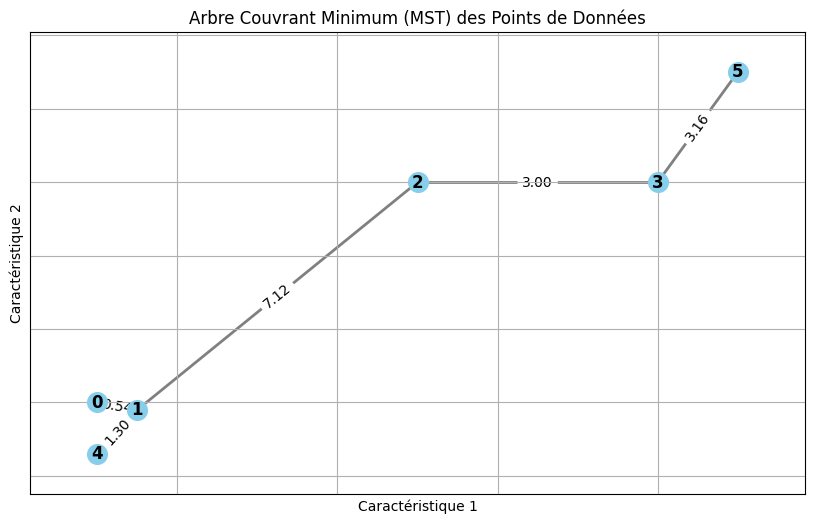

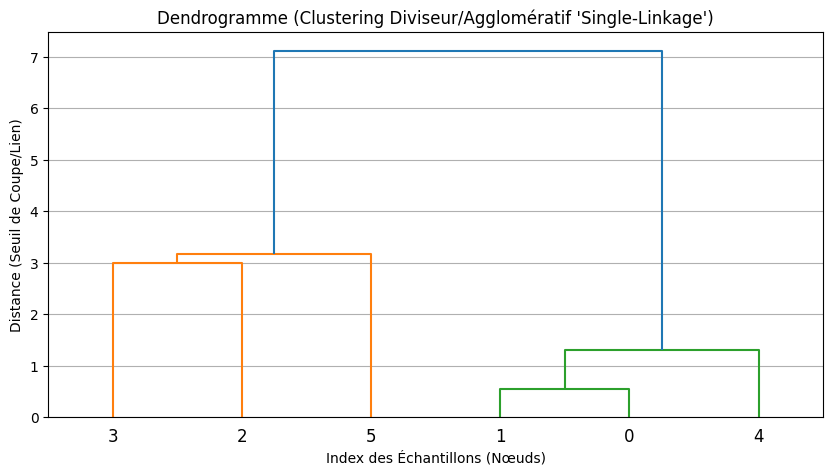

In [3]:
# ----------------------------------------------------
## A. AFFICHAGE DE L'ARBRE COUVRANT MINIMUM (MST)
# ----------------------------------------------------

# Créer un graphe NetworkX à partir des arêtes du MST
G_mst = nx.Graph()
G_mst.add_nodes_from(range(n_nodes))
G_mst.add_edges_from(mst_edges)

# Définir la position des nœuds (les coordonnées des points de données)
pos = {i: X[i] for i in range(n_nodes)}
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G_mst.edges(data=True)}

plt.figure(figsize=(10, 6))
plt.title("Arbre Couvrant Minimum (MST) des Points de Données")

# Dessiner les nœuds et les points de données
nx.draw_networkx_nodes(G_mst, pos, node_size=200, node_color='skyblue')
# Dessiner les arêtes du MST
nx.draw_networkx_edges(G_mst, pos, width=2, edge_color='gray')
# Afficher l'étiquette (l'indice) de chaque nœud
nx.draw_networkx_labels(G_mst, pos, font_weight='bold')
# Afficher les poids des arêtes
nx.draw_networkx_edge_labels(G_mst, pos, edge_labels=edge_labels)

plt.grid(True)
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.axis('on')
plt.show()


# ----------------------------------------------------
## B. AFFICHAGE DU DENDROGRAMME (Clustering Diviseur basé sur le MST)
# ----------------------------------------------------

# La construction du dendrogramme repose sur la même logique hiérarchique :
# L'approche MST divisive est équivalente à une approche agglomérative (ascendante)
# utilisant la distance du "lien simple" (single-linkage), qui est basée sur les
# plus petites distances entre les clusters. Les poids d'arête du MST représentent
# les distances critiques des fusions/divisions.

# Pour générer le dendrogramme, nous utilisons la matrice des distances et le 'single-linkage'.
# Le single-linkage garantit que l'ordre des fusions correspond aux arêtes du MST.
# C'est l'inverse exact de la division par l'arête maximale.

linked = linkage(X, 'single')

plt.figure(figsize=(10, 5))
plt.title("Dendrogramme (Clustering Diviseur/Agglomératif 'Single-Linkage')")
plt.xlabel("Index des Échantillons (Nœuds)")
plt.ylabel("Distance (Seuil de Coupe/Lien)")

# Dessiner le dendrogramme
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.grid(axis='y')
plt.show()